In [ ]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [ ]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [ ]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [ ]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [ ]:
rain_file_origin_path = '../data/Rainfall.csv'
rain_origin_data = pd.read_csv(rain_file_origin_path)
rain_file_path = '../data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "../data/test.csv"
test_data = pd.read_csv(test_file_path)

In [ ]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [ ]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [ ]:
score_dataset(X, y)

0.8776175077070999


In [ ]:
y_origin = rain_origin_data["rainfall"]

In [ ]:
X_origin = rain_origin_data.drop(labels="rainfall", axis=1)

In [ ]:
X_origin = X_origin.drop(labels="day", axis=1)
X_test = X_test.drop(labels="day", axis=1)

In [ ]:
X = X.drop(labels="id", axis=1)
X_test = X_test.drop(labels="id", axis=1)

In [ ]:
X = X.drop(labels="day", axis=1)

In [ ]:
X_origin.rename(columns={'pressure ': 'pressure', 'humidity ': 'humidity', '         winddirection': 'winddirection', 'cloud ':'cloud' }, inplace=True)

In [ ]:

y_origin = y_origin.replace({"yes": 1, "no": 0})

/var/folders/g_/xlgpd__x3y70c42xrmy8vz5h0000gn/T/ipykernel_4418/425826855.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_origin = y_origin.replace({"yes": 1, "no": 0})


In [ ]:
y_origin

0      1
1      1
2      1
3      1
4      1
      ..
361    1
362    1
363    1
364    1
365    0
Name: rainfall, Length: 366, dtype: int64

In [ ]:
X = pd.concat([X, X_origin], ignore_index=True)
y = pd.concat([y, y_origin], ignore_index=True)

In [ ]:
X.isnull().sum()

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        1
dtype: int64

In [ ]:
winddirection_nan = X.winddirection.isnull()
winddirection_nan.loc[winddirection_nan == True]

2350    True
Name: winddirection, dtype: bool

In [ ]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,NaN,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [ ]:
X.winddirection.fillna(205.0, inplace=True)

/var/folders/g_/xlgpd__x3y70c42xrmy8vz5h0000gn/T/ipykernel_4418/1166324537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.winddirection.fillna(205.0, inplace=True)


In [ ]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,NaN
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [ ]:
X.windspeed.fillna(13.6, inplace=True)

/var/folders/g_/xlgpd__x3y70c42xrmy8vz5h0000gn/T/ipykernel_4418/3718298068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.windspeed.fillna(13.6, inplace=True)


In [ ]:
X.loc[2345:2355, :]

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
2345,1007.9,33.8,28.7,24.7,25.4,83.0,75.0,5.5,220.0,20.8
2346,1008.8,30.4,26.9,25.0,24.3,86.0,87.0,0.7,20.0,9.8
2347,1008.8,29.1,26.2,24.8,24.7,91.0,80.0,2.2,20.0,11.2
2348,1008.1,30.7,28.1,26.3,25.4,86.0,75.0,5.7,20.0,9.5
2349,1006.3,30.0,27.1,24.1,25.1,89.0,85.0,3.1,190.0,12.6
2350,1005.7,31.7,28.2,26.6,25.7,86.0,79.0,6.5,205.0,13.6
2351,1005.7,31.1,27.9,26.6,25.8,89.0,80.0,4.5,220.0,14.6
2352,1005.9,27.8,26.6,25.4,25.4,93.0,85.0,0.0,230.0,20.0
2353,1005.7,29.2,27.1,25.4,25.8,93.0,96.0,0.0,220.0,29.8
2354,1005.0,31.5,29.7,28.5,26.7,84.0,90.0,1.3,220.0,24.3


In [ ]:
y

0       1
1       1
2       1
3       1
4       0
       ..
2551    1
2552    1
2553    1
2554    1
2555    0
Name: rainfall, Length: 2556, dtype: int64

In [ ]:
#train2_1 = X
#train2_1["rainfall"] = y
#train2_1.to_csv('train2_1.csv')
#train2_1

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...
2551,1022.7,18.8,17.7,16.9,15.0,84.0,90.0,0.0,30.0,18.4,1
2552,1026.6,18.6,17.3,16.3,12.8,75.0,85.0,1.0,20.0,25.9,1
2553,1025.9,18.9,17.7,16.4,13.3,75.0,78.0,4.6,70.0,33.4,1
2554,1025.3,19.2,17.3,15.2,13.3,78.0,86.0,1.2,20.0,20.9,1


In [ ]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.225528
sunshine         0.177870
humidity         0.146522
dewpoint         0.041666
maxtemp          0.035362
temparature      0.023822
mintemp          0.022473
pressure         0.018506
windspeed        0.017216
winddirection    0.000000
Name: MI Scores, dtype: float64

In [ ]:
#cols = X.columns
cols = ["cloud", "sunshine", "humidity"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity
0,88.0,1.1,87.0
1,91.0,0.0,95.0
2,47.0,8.3,75.0
3,95.0,0.0,95.0
4,45.0,3.6,52.0
...,...,...,...
2551,90.0,0.0,84.0
2552,85.0,1.0,75.0
2553,78.0,4.6,75.0
2554,86.0,1.2,78.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity
0,0.88,0.090909,0.822581
1,0.91,0.000000,0.951613
2,0.47,0.685950,0.629032
3,0.95,0.000000,0.951613
4,0.45,0.297521,0.258065
...,...,...,...
2551,0.90,0.000000,0.774194
2552,0.85,0.082645,0.629032
2553,0.78,0.380165,0.629032
2554,0.86,0.099174,0.677419


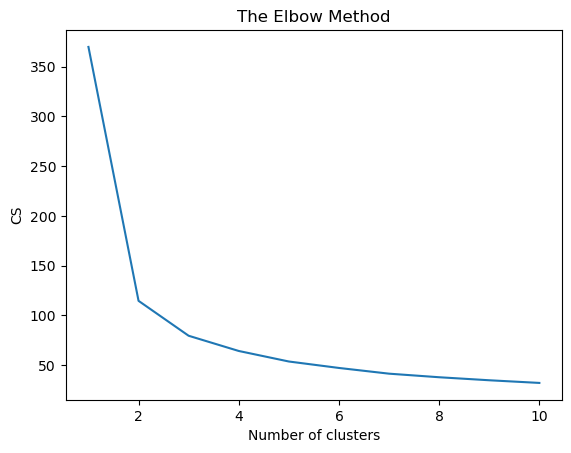

In [ ]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 2010 out of 2556 samples were correctly labeled.
Accuracy score: 0.79


In [ ]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1769 out of 2556 samples were correctly labeled.
Accuracy score: 0.69


In [ ]:
kmeans = KMeans(n_clusters=4, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1291 out of 2556 samples were correctly labeled.
Accuracy score: 0.51


In [ ]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)

In [ ]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [ ]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [ ]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [ ]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,Centroid_2,Centroid_3,cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.320980,2.007112,0.056627,1.130346,1
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.407856,2.026027,0.130218,1.197359,1
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0.115882,3.057684,1.279151,2.018742,0
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,1.422300,2.028303,0.143294,1.204653,1
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2.087419,1.167456,1.258566,0.581553,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.382903,2.018818,0.068296,1.180704,1
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.382903,2.018818,0.068296,1.180704,1
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.356186,2.012948,0.154280,1.162345,1
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.356143,2.013098,0.139579,1.165467,1


In [ ]:
score_dataset(X, y)

0.8840953304981938


In [ ]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

Centroid_1       0.219203
Centroid_2       0.205577
Centroid_0       0.196783
Centroid_3       0.196678
cloud            0.196587
cluster          0.183192
sunshine         0.166513
humidity         0.123925
temparature      0.033474
dewpoint         0.029429
maxtemp          0.028643
windspeed        0.024141
winddirection    0.018389
pressure         0.008075
mintemp          0.000000
Name: MI Scores, dtype: float64

In [ ]:
score_dataset(X, y)

0.8840953304981938


In [ ]:
X = X.drop(labels = ("winddirection"), axis=1)
X_test = X_test.drop(labels = ("winddirection"), axis=1)
score_dataset(X, y)

0.882160855283159


In [ ]:
#X = X.drop(labels = ("winddirection"), axis=1)
#X_test = X_test.drop(labels = ("winddirection"), axis=1)
#score_dataset(X, y)

In [ ]:
features = ["cloud", "cluster", "Centroid_1", "Centroid_0", "humidity", "sunshine", "Centroid_2", "Centroid_3", "temparature"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                  PC1       PC2       PC3       PC4       PC5       PC6  \
cloud       -0.337939 -0.392890 -0.030664 -0.024602  0.278284 -0.802669   
cluster     -0.462555  0.197961  0.076356 -0.055644 -0.018465  0.068158   
Centroid_1   0.468675 -0.176571 -0.058414  0.051639  0.012016 -0.070219   
Centroid_0  -0.473971  0.136767  0.102557 -0.082607  0.018937  0.108009   
humidity    -0.167845 -0.401154 -0.430617 -0.395617 -0.680920  0.063497   
sunshine     0.254872  0.458734 -0.196750  0.228213 -0.411936 -0.522791   
Centroid_2  -0.139801  0.546506  0.183314 -0.318956 -0.202034 -0.199528   
Centroid_3   0.338909 -0.004390  0.308261 -0.786507  0.151318 -0.116898   
temparature  0.000042  0.294137 -0.791536 -0.240599  0.473979  0.060517   

                  PC7       PC8       PC9  
cloud       -0.088141  0.018755  0.007046  
cluster      0.233843 -0.150065  0.809778  
Centroid_1  -0.140559  0.688431  0.494286  
Centroid_0   0.392655  0.688887 -0.313905  
humidity    -0.033210  0.0114

In [ ]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,Centroid_0,...,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1.320980,...,1,0.271984,-1.965026,0.025719,0.167662,0.029920,-0.025333,0.119047,-0.044759,0.003605
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1.407856,...,1,-0.029428,-2.702951,0.274620,-0.251059,-0.799313,-0.002719,-0.034519,0.039289,-0.001302
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,0.115882,...,0,3.553979,0.457516,1.523644,-0.062176,-0.872197,-0.195638,-0.122452,-0.093856,0.016346
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1.422300,...,1,-0.105752,-2.726165,0.141585,-0.313801,-0.660161,-0.167743,-0.058030,0.059375,-0.003416
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,2.087419,...,2,0.212920,2.135731,2.323471,2.266921,1.351376,1.176985,0.027744,-0.028937,0.020331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1022.7,18.8,17.7,16.9,15.0,84.0,90.0,0.0,18.4,1.370911,...,1,0.222478,-2.146485,0.702507,0.310366,0.181428,-0.017226,0.037927,-0.015117,-0.002631
2552,1026.6,18.6,17.3,16.3,12.8,75.0,85.0,1.0,25.9,3.111506,...,3,-2.358977,0.809546,2.056986,-0.251295,0.163629,-0.067541,-0.108878,0.012442,0.019431
2553,1025.9,18.9,17.7,16.4,13.3,75.0,78.0,4.6,33.4,3.048922,...,3,-2.007728,1.438145,1.761005,0.095796,-0.343785,-0.269584,0.230314,-0.024994,0.018706
2554,1025.3,19.2,17.3,15.2,13.3,78.0,86.0,1.2,20.9,3.110026,...,3,-2.443865,0.669553,1.883588,-0.374558,-0.094849,-0.110843,-0.099331,-0.007754,0.004296


In [ ]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [ ]:
#když bylo vyhozené id a day bylo to 0.8745862843729195
score_dataset(X, y)

0.8815636104234887


In [ ]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

Centroid_1     0.222114
PC1            0.220558
cloud          0.218239
Centroid_2     0.205845
Centroid_0     0.200512
cluster        0.198695
Centroid_3     0.197758
sunshine       0.165697
humidity       0.145527
PC2            0.125871
PC9            0.078966
PC6            0.051926
PC4            0.044791
PC3            0.039009
temparature    0.038699
PC8            0.036012
dewpoint       0.033170
mintemp        0.022122
pressure       0.018645
maxtemp        0.017859
PC7            0.015866
windspeed      0.000000
PC5            0.000000
Name: MI Scores, dtype: float64

In [ ]:
X = X.drop(labels = ("PC5"), axis=1)
X_test = X_test.drop(labels = ("PC5"), axis=1)
score_dataset(X, y)

0.881489801993304


In [ ]:
X = X.drop(labels = ("windspeed"), axis=1)
X_test = X_test.drop(labels = ("windspeed"), axis=1)
score_dataset(X, y)

0.8780464133405316


In [ ]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=1,
    class_weight="balanced",
    solver="liblinear",
)
score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(score.mean())

0.8934427948954451


In [ ]:
%%time
from sklearn.model_selection import GridSearchCV
cross_valid_scores = {}
parameters = {
    "C": [0.001, 0.01, 0.1, 1.],
    "penalty": ["l1", "l2"]
}

model_logistic_regression = LogisticRegression(
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

model_logistic_regression = GridSearchCV(
    model_logistic_regression,
    parameters,
    cv=5,
    scoring='roc_auc',
)

model_logistic_regression.fit(X, y)

print('-----')
print(f'Best parameters {model_logistic_regression.best_params_}')
print(
    f'Mean cross-validated accuracy score of the best_estimator: ' +
    f'{model_logistic_regression.best_score_:.3f}'
)
cross_valid_scores['logistic_regression'] = model_logistic_regression.best_score_
print('-----')

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/sklearn/svm/_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/DataScience/lib/python3.11/sit

-----
Best parameters {'C': 0.01, 'penalty': 'l2'}
Mean cross-validated accuracy score of the best_estimator: 0.894
-----
CPU times: user 9.79 s, sys: 158 ms, total: 9.95 s
Wall time: 12.7 s


In [ ]:
model_logistic_regression = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)

In [ ]:
model_logistic_regression.fit(X, y)
rf_test_preds = model_logistic_regression.predict(X_test)

In [ ]:
X_test["id"] = test_data["id"]
X_test["rainfall"] = rf_test_preds
X_test.to_csv('submission_2dts_k-mean_PCA_4_clusters.csv', columns=['id','rainfall'], index=False)